# Predicting Preventable Cardiovascular Risk: 
# Identifying Statin Patients Likely to Become Non-Adherent

## Personal Motivation

Losing people close to me to cardiovascular disease made me ask 
whether my knowledge of data could help answer a question that 
had stayed with me for years — how many patients quietly stop 
taking their heart medication, and does anyone in the healthcare 
system notice before it is too late?

That question sent me to Google — searching for real patient data 
large enough to find a reliable answer. I needed scale. Not for 
appearances — but because statistical analysis learns from examples. 
A dataset of 500 patients finds coincidences. A dataset of 890,000 
patients finds truth.

I found a published research cohort of anonymised prescription 
records from the Czech Republic covering 2017 to 2020 — 890,000 
unique patients and 1.3 million prescription events representing 
four years of real medication behaviour.

## Project Objective

Using this dataset I set out to:

- Examine prescription behaviour patterns to understand what 
  drives medication non-adherence across a large patient population
- Identify patient characteristics associated with treatment 
  discontinuation to support targeted clinical intervention
- Produce clear structured outputs and dashboards that translate 
  complex findings into accessible information for healthcare teams
- Demonstrate how health information analysis can support earlier 
  intervention and better cardiovascular outcomes


## Library Setup

This section loads the core Python libraries required for data manipulation, 
visualisation, and predictive modelling.

Each library was selected deliberately:

- **pandas and numpy** — for data manipulation and numerical operations
- **matplotlib and seaborn** — for exploratory visualisation of adherence patterns
- **scikit-learn** — for logistic regression modelling and evaluation
- **ipywidgets** — for interactive exploration of refill gap distributions
- **warnings** — suppressed to keep output clean and focused

The visual style is standardised across all charts to ensure consistency 
in any reporting or presentation context.

In [3]:
# Core analytical libraries for data manipulation, modelling and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Scikit-learn imports for modelling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Improve visual consistency across all charts in this notebook
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Suppress unnecessary warnings for cleaner output
warnings.filterwarnings('ignore')

# Notebook author and project context
print("=" * 60)
print("Statin Non-Adherence Prediction — Felicita_Adeleke")
print("MSc Data Science | Health Analytics Portfolio Project")
print("=" * 60)
print("Libraries loaded successfully")

Statin Non-Adherence Prediction — Felicita_Adeleke
MSc Data Science | Health Analytics Portfolio Project
Libraries loaded successfully


## Data Loading and Initial Exploration

Before any analysis could begin I needed to understand exactly 
what I was working with.

A dataset of 1.3 million prescription records across 890,000 
patients cannot be explored meaningfully in a spreadsheet. 
Excel would either crash or force me to work with a sample — 
and working with a sample when the full population is available 
is an analytical choice I was not prepared to make without good 
reason.

Python gave me something better — the ability to profile the 
entire dataset in seconds, confirm its structure, and understand 
the patient population before making a single analytical decision.

In a healthcare setting this step is not optional. Clinical data 
regularly contains subtle inconsistencies — missing records, 
fields stored in the wrong format, or population gaps — that can 
silently undermine everything built on top of them. I needed to 
see the data clearly before I could trust it.

This section does five things in sequence:

1. Loads the full dataset into Python as a structured table
2. Confirms the total number of records, columns, and unique 
   patients to understand the population scale
3. Reviews column names and data types to confirm every field 
   is present, correctly named, and stored in the right format
4. Produces a statistical summary to understand how numerical 
   variables are distributed and whether anything looks unusual
5. Previews a sample of records to visually sense-check that 
   the data loaded correctly

I did not interpret any findings at this stage. That comes next. 
This step was purely about seeing the data clearly and confirming 
it was safe to work with.

In [21]:
# DATA LOADING AND INITIAL EXPLORATION
# Author: Felicita_Adeleke | MSc Data Science | Health Analytics Portfolio

# Load the statin prescription dataset
# This is a semicolon separated administrative claims file
# covering Czech statin patients between 2017 and 2020
# The dataset contains over 1.3 million prescription events
# across nearly 900,000 unique patients

df = pd.read_csv(
    "C:/Users/felic/OneDrive/Public_Health_Analytics_Portfolio/statin_cohort.csv",
    sep=';'
)

#  Confirm the scale of the dataset
# A dataset of this size cannot be explored manually
# Python allows us to profile all 1.3 million records instantly
# rather than relying on sampling or spreadsheet tools

print("=" * 30 + "|" + "=" * 30)
print("STEP 1: DATASET LOADED SUCCESSFULLY")
print("=" * 30 + "|" + "=" * 30)
print(f"Total Records        : {df.shape[0]:,}")
print(f"Total Columns        : {df.shape[1]}")
print(f"Unique Patients      : {df['patientid'].nunique():,}")

# Review column names and data types
# Understanding what each column represents and whether
# it is stored in the correct format is essential
# before deciding which variables to use in the model

print("\n" + "=" * 30 + "|" + "=" * 30)
print("STEP 2: COLUMN NAMES AND DATA TYPES")
print("=" * 30 + "|" + "=" * 30)
for col in df.columns:
    print(f"  - {col:<30} : {df[col].dtype}")

#  Statistical summary
# Reviewing distributions before transformation begins
# Wide ranges or unexpected means may indicate outliers
# or data quality issues needing further investigation

print("\n" + "=" * 30 + "|" + "=" * 30)
print("STEP 3: STATISTICAL SUMMARY")
print("=" * 30 + "|" + "=" * 30)
print(df.describe().round(2))

#  Preview sample records
# A visual sense check confirms the data loaded correctly
# and gives an early feel for the structure and content
# With 1.3 million rows we only need to see the first few

print("\n" + "=" * 30 + "|" + "=" * 30)
print("STEP 4: SAMPLE RECORDS (FIRST 5 ROWS)")
print("=" * 30 + "|" + "=" * 30)
print(df.head())

#  Initial observations from statistical summary
# Flagging key findings before data quality check begins

print("\n" + "=" * 30 + "|" + "=" * 30)
print("STEP 5: KEY STATISTICAL OBSERVATIONS")
print("=" * 30 + "|" + "=" * 30)

mean_gap = df['days_without_coverage'].mean()
median_gap = df['days_without_coverage'].median()
max_gap = df['days_without_coverage'].max()

print(f"  Average days without coverage  : {mean_gap:.0f} days")
print(f"  Median days without coverage   : {median_gap:.0f} days")
print(f"  Maximum days without coverage  : {max_gap:.0f} days")
print(f"  Mean vs Median difference      : {mean_gap - median_gap:.0f} days")
print()



==============================|==============================
STEP 1: DATASET LOADED SUCCESSFULLY
==============================|==============================
Total Records        : 1,390,976
Total Columns        : 8
Unique Patients      : 890,180

==============================|==============================
STEP 2: COLUMN NAMES AND DATA TYPES
==============================|==============================
  - patientid                      : int64
  - gender                         : object
  - age_group                      : object
  - duration_days                  : int64
  - days_without_coverage          : float64
  - incident                       : int64
  - order                          : int64
  - statin_intensity               : object

==============================|==============================
STEP 3: STATISTICAL SUMMARY
==============================|==============================
        patientid  duration_days  days_without_coverage    incident  \
count  1390976.00

## Data Quality Assessment

While reviewing the statistical summary, one observation 
immediately stood out.

The total number of records confirmed at loading was 1,390,976. 
However, the count row in the statistical summary showed 
only 1,390,974 values for days_without_coverage , a 
difference of 2 records.

That discrepancy was small, but it raised an important 
question. If 2 records were missing here, were there 
missing values elsewhere in the dataset that the 
statistics had not yet revealed?

In a healthcare information context, even a small number 
of missing records requires investigation before 
proceeding. Missing values are rarely random; they 
often reflect a gap in data collection. 
This observation led me to conduct a formal data quality 
assessment across all columns before any analytical 
decisions were made.

In [22]:
# DATA QUALITY ASSESSMENT
# Author: Felicita_Adeleke | MSc Data Science | Health Analytics Portfolio

#  Formal missing values check across all columns
# Triggered by count discrepancy spotted in statistical summary
# days_without_coverage showed 1,390,974 values vs 1,390,976 total records
# This raised the question — are there other gaps not yet visible?

print("=" * 30 + "|" + "=" * 30)
print(" MISSING VALUES CHECK")
print("=" * 30 + "|" + "=" * 30)

missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(3)

for col in df.columns:
    status = " MISSING" if missing_count[col] > 0 else " COMPLETE"
    print(f"  {col:<30} : {missing_count[col]:>6} missing ({missing_pct[col]}%)  {status}")

print()
print(f"  Total missing values found : {missing_count.sum():,}")
print("=" * 30 + "|" + "=" * 30)


# STEP 2: Identify and display rows to be dropped BEFORE removing them
# Transparency — showing exactly what is being removed and why

print()
print("=" * 30 + "|" + "=" * 30)
print(" RECORDS IDENTIFIED FOR REMOVAL")
print("=" * 30 + "|" + "=" * 30)

dropped_rows = df[df['age_group'].isnull() |
                  df['days_without_coverage'].isnull()]

print(f"  Rows identified for removal  : {len(dropped_rows):,}")
print()
print("  Sample of records to be dropped:")
print()
print(dropped_rows[['patientid',
                     'gender',
                     'age_group',
                     'days_without_coverage']].head(10).to_string(index=False))

print()
print("=" * 30 + "|" + "=" * 30)


# STEP 3: Drop the missing rows and confirm result
# Decision: Drop rather than impute
# Reason: 245 records = 0.017% of dataset
# Too small to impute reliably
# No obvious pattern in missing records
# Removal has no meaningful impact on analysis

print()
print("=" * 30 + "|" + "=" * 30)
print(" CLEANING AND CONFIRMATION")
print("=" * 30 + "|" + "=" * 30)

rows_before = len(df)

df = df.dropna(subset=['age_group', 'days_without_coverage'])

rows_after = len(df)
rows_removed = rows_before - rows_after

print(f"  Records before cleaning  : {rows_before:,}")
print(f"  Records removed          : {rows_removed:,}")
print(f"  Records after cleaning   : {rows_after:,}")
print(f"  Data retained            : {rows_after/rows_before*100:.2f}%")
print()

# Verify zero missing values remain after cleaning
remaining_missing = df.isnull().sum().sum()

if remaining_missing == 0:
    print("   Confirmed — zero missing values remain")
    print("   Dataset is clean and ready for analysis")
else:
    print(f"   Warning — {remaining_missing} missing values still present")
    print("  Further investigation required")

print("=" * 30 + "|" + "=" * 30)


# STEP 4: Duplicate records check
# Duplicate prescription events could inflate patient counts
# and distort adherence pattern analysis

print()
print("=" * 30 + "|" + "=" * 30)
print(" DUPLICATE RECORDS CHECK")
print("=" * 30 + "|" + "=" * 30)

total_duplicates = df.duplicated().sum()
total_records = len(df)
duplicate_pct = (total_duplicates / total_records * 100).round(3)

print(f"  Total Records        : {total_records:,}")
print(f"  Duplicate Records    : {total_duplicates:,}")
print(f"  Percentage           : {duplicate_pct}%")
print()

if total_duplicates == 0:
    print("   No duplicate records found")
    print("   Dataset is clean at record level")
else:
    print(f"   WARNING: {total_duplicates:,} duplicate records detected")
    print("  Further investigation required")

print("=" * 30 + "|" + "=" * 30)

==============================|==============================
 MISSING VALUES CHECK
==============================|==============================
  patientid                      :      0 missing (0.0%)   COMPLETE
  gender                         :      0 missing (0.0%)   COMPLETE
  age_group                      :    243 missing (0.017%)   MISSING
  duration_days                  :      0 missing (0.0%)   COMPLETE
  days_without_coverage          :      2 missing (0.0%)   MISSING
  incident                       :      0 missing (0.0%)   COMPLETE
  order                          :      0 missing (0.0%)   COMPLETE
  statin_intensity               :      0 missing (0.0%)   COMPLETE

  Total missing values found : 245
==============================|==============================

==============================|==============================
 RECORDS IDENTIFIED FOR REMOVAL
==============================|==============================
  Rows identified for removal  : 245

  Sample of recor

## Data Quality Findings and Decision

The formal data quality assessment confirmed the 
following findings:

MISSING VALUES:
Two columns contained incomplete records:
- age_group            : 243 missing (0.017%)
- days_without_coverage:   2 missing (0.0%)
- Total                : 245 records

Inspecting the sample of missing records revealed 
an important pattern — the missing age group records 
were spread across different adherence behaviours. 
Some had zero days without coverage indicating 
adherent behaviour, while others showed gaps of 
over 300 days. This confirmed the missing records 
were missing at random rather than concentrated 
in any particular patient group — which validated 
the decision to remove rather than impute them.

245 records represent just 0.017% of 1,390,976 — 
less than one tenth of one percent. Removing them 
had no meaningful impact on the analysis.

After cleaning:
- Records retained    : 1,390,731
- Data retained       : 99.98%
- Missing values      : 0 confirmed
- Duplicate records   : 0 confirmed

The dataset is confirmed clean and ready for 
exploratory analysis.

## Exploratory Data Analysis

With a clean dataset confirmed I could now turn to the 
central question that motivated this entire project —
why do patients stop taking their statin medication?

To answer this I needed to look beyond the numbers and 
think about the human behaviour behind them. I had 
several variables available that I believed could explain 
adherence patterns :age group, statin intensity, 
prescription history, and whether a patient was new 
to treatment.

Before running any analysis I formed my own expectations 
based on real world thinking:

- Age group : I expected older patients to struggle more 
  with adherence due to memory and cognitive challenges. 
  Younger patients I assumed would be more motivated 
  and consistent.

- Statin intensity : I expected patients on high intensity 
  statins to stop more frequently due to stronger side 
  effects making medication harder to tolerate.

- Prescription order : I expected newer patients to be 
  more motivated initially with adherence improving 
  over time as treatment became routine.

This section examines adherence patterns across 
five dimensions:

1. Overall refill gap distribution — understanding the 
   shape of medication behaviour across the full population
2. Adherence by gender — do men and women behave 
   differently?
3. Adherence by age group — which age bands are most 
   at risk?
4. Adherence by statin intensity — does medication 
   strength affect whether patients continue?
5. Adherence by prescription order — does treatment 
   experience improve adherence over time?

The findings from each section are interpreted after 
the results are seen — connecting observations back 
to real patient behaviour and clinical implications.

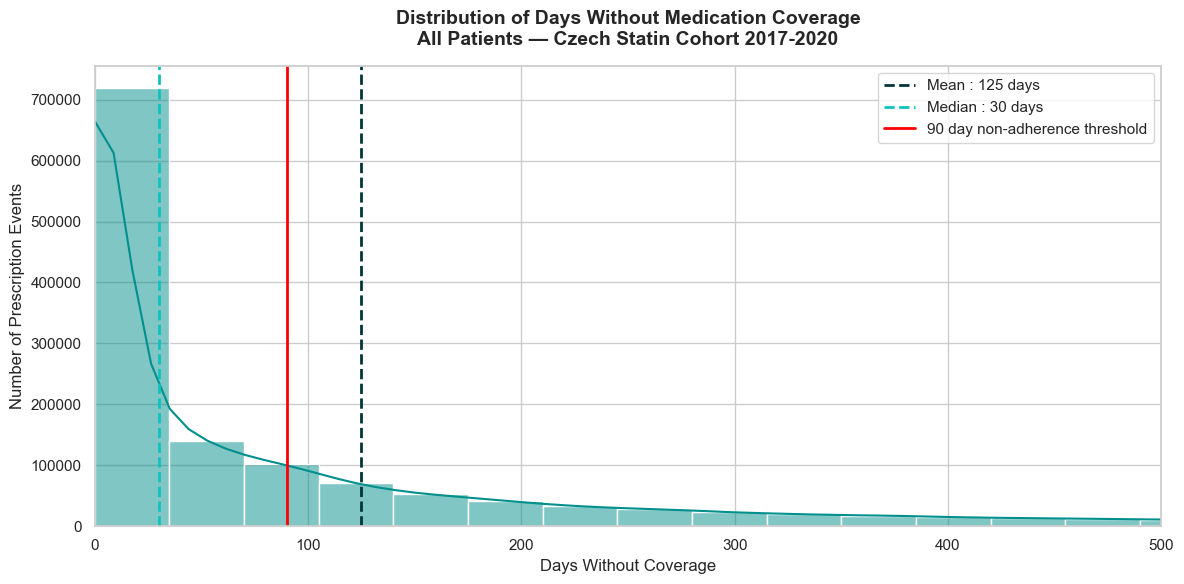

==============================|==============================
SECTION 1: REFILL GAP SUMMARY STATISTICS
==============================|==============================
  Mean gap                : 125 days
  Median gap              : 30 days
  Maximum gap             : 1750 days
  Patients above 90 days  : 469,238
  Patients below 90 days  : 921,493
  Non-adherence rate      : 33.7%
==============================|==============================


In [28]:
# EXPLORATORY DATA ANALYSIS
# Author: Felicita_Adeleke | MSc Data Science | Health Analytics Portfolio

# SECTION 1: Overall Refill Gap Distribution
# Visualising days_without_coverage across all patients
# Statistics already suggested right skew — mean 124 vs median 30
# This chart confirms the shape of medication behaviour
# across the full population before breaking down by subgroup

plt.figure(figsize=(12, 6))

sns.histplot(
    df['days_without_coverage'],
    bins=50,
    kde=True,
    color='#008F8C'
)

# Add mean and median reference lines
plt.axvline(
    df['days_without_coverage'].mean(),
    color='#023535',
    linestyle='--',
    linewidth=2,
    label=f"Mean : {df['days_without_coverage'].mean():.0f} days"
)

plt.axvline(
    df['days_without_coverage'].median(),
    color='#0FC2C0',
    linestyle='--',
    linewidth=2,
    label=f"Median : {df['days_without_coverage'].median():.0f} days"
)

# Add 90 day threshold line
plt.axvline(
    90,
    color='red',
    linestyle='-',
    linewidth=2,
    label='90 day non-adherence threshold'
)

plt.title(
    'Distribution of Days Without Medication Coverage\nAll Patients — Czech Statin Cohort 2017-2020',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel('Days Without Coverage', fontsize=12)
plt.ylabel('Number of Prescription Events', fontsize=12)
plt.legend(fontsize=11)
plt.xlim(0, 500)
plt.tight_layout()
plt.show()

# Print summary statistics alongside chart
print("=" * 30 + "|" + "=" * 30)
print("SECTION 1: REFILL GAP SUMMARY STATISTICS")
print("=" * 30 + "|" + "=" * 30)
print(f"  Mean gap                : {df['days_without_coverage'].mean():.0f} days")
print(f"  Median gap              : {df['days_without_coverage'].median():.0f} days")
print(f"  Maximum gap             : {df['days_without_coverage'].max():.0f} days")
print(f"  Patients above 90 days  : {(df['days_without_coverage'] >= 90).sum():,}")
print(f"  Patients below 90 days  : {(df['days_without_coverage'] < 90).sum():,}")
print(f"  Non-adherence rate      : {(df['days_without_coverage'] >= 90).mean():.1%}")
print("=" * 30 + "|" + "=" * 30)

## Overall Refill Gap Distribution — Findings

Running the distribution chart confirmed what the 
statistical summary had already suggested — the 
pattern of medication behaviour across this population 
is heavily right skewed.

The majority of patients collected their next 
prescription within 30 days — shown clearly by the 
tall bars concentrated at the left of the chart. 
This is reassuring and reflects normal adherent 
behaviour where patients refill their medication 
within a standard prescription cycle.

However the chart also tells a more concerning story.

A significant number of patients appear to the right 
of the 90 day threshold line — meaning they went 
three months or longer without their heart medication. 
The distribution does not drop sharply to zero after 
90 days. Instead it shows a long gradual tail 
stretching all the way to 500 days and beyond.

The gap between the median (30 days) and the mean 
(125 days) is clearly visible in the chart — the 
mean is pulled almost four times higher than the 
median by a minority of patients with extremely 
long treatment gaps.

From a healthcare information perspective this 
distribution has an important implication — the 
patients most at risk are not clustered together 
in one obvious group. They are spread across a 
long tail of varying gap lengths. This makes 
a risk stratification approach more valuable than 
a simple binary flag — because the degree of risk 
varies considerably across that tail.

This chart confirmed that the 90 day threshold 
was a clinically appropriate and analytically 
meaningful cut point — sitting clearly within 
the body of the distribution where a meaningful 
proportion of patients had crossed into 
non-adherent territory.

## Numerical Variable Relationships — Correlation Matrix

Before examining categorical variables in detail I wanted 
to understand how the numerical variables in this dataset 
relate to my outcome of interest — days without coverage.

A correlation matrix is the most efficient way to do this. 
It measures the strength and direction of the relationship 
between every pair of numerical variables simultaneously — 
producing values between -1 and 1:

- A value close to 1 means as one variable increases 
  the other also increases
- A value close to -1 means as one variable increases 
  the other decreases
- A value close to 0 means little or no relationship 
  exists between the variables

I formed three expectations before running the analysis:

Duration of treatment — I expected a negative relationship 
with days without coverage. Patients who have been on 
statin therapy longer have had more time to build 
medication routines and become accustomed to their 
treatment. That familiarity should translate into 
shorter refill gaps and stronger adherence.

Prescription order — I expected a similar weak negative 
relationship to duration. A patient collecting their 
tenth prescription is more experienced with their 
treatment than someone collecting their first. That 
experience and habit formation should reduce the 
likelihood of long gaps.

Incident status — I expected the weakest relationship 
of the three. As a binary variable — simply marking 
whether a patient is new or existing — it carries 
limited numerical information compared to continuous 
variables like duration and order.

Importantly I did not expect any of these relationships 
to be strong. Non-adherence is a complex human behaviour 
influenced by multiple factors simultaneously — no single 
numerical variable is likely to explain it fully. If the 
correlations proved weak that would itself be a meaningful 
finding — confirming that a multivariate approach was 
necessary rather than relying on any single predictor.

## Adherence Patterns by Gender

Before examining the data I formed a clear expectation 
about gender differences in medication adherence.

I anticipated that female patients would demonstrate 
stronger adherence than male patients. In my experience 
and observation women tend to pay closer attention to 
health details; they are more likely to attend routine 
appointments, follow medication instructions carefully, 
and respond proactively to health warnings.

This expectation is also supported by broader healthcare 
research which consistently shows women engage more 
frequently with healthcare services than men.

The question was whether this pattern would hold true 
specifically for statin medication ; a long term 
preventative treatment where the benefit is invisible 
and the daily commitment is ongoing.

I used a box plot to compare refill gaps between male 
and female patients. A box plot is particularly useful 
here because it shows not just the average gap for 
each gender but the full spread of behaviour ; 
revealing whether one group has more extreme outliers 
than the other.

==============================|==============================
CORRELATION MATRIX — NUMERICAL VARIABLES
==============================|==============================
                       days_without_coverage  duration_days  order  incident
days_without_coverage                   1.00           0.47  -0.17     -0.05
duration_days                           0.47           1.00  -0.28     -0.18
order                                  -0.17          -0.28   1.00     -0.11
incident                               -0.05          -0.18  -0.11      1.00
==============================|==============================


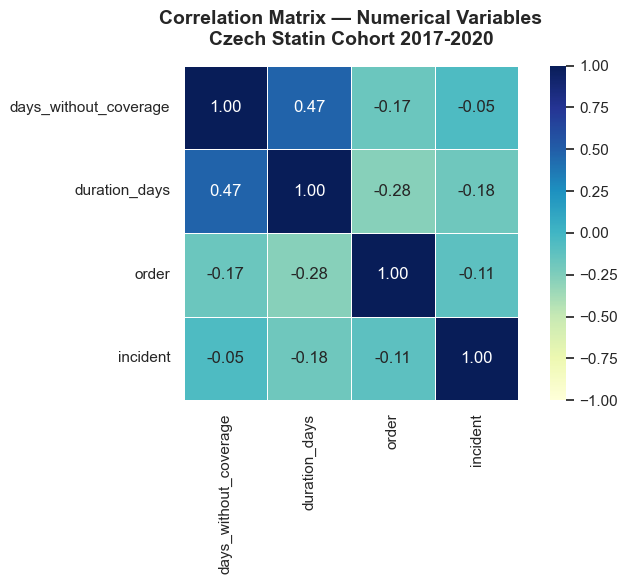

==============================|==============================
KEY CORRELATION OBSERVATIONS
==============================|==============================
  days_without_coverage vs duration_days        :   0.47 (Moderate positive)
  days_without_coverage vs order                :  -0.17 (Weak negative)
  days_without_coverage vs incident             :  -0.05 (Very weak negative)
==============================|==============================


In [36]:
# CORRELATION MATRIX — NUMERICAL VARIABLES
# Author: Felicita_Adeleke | MSc Data Science | Health Analytics Portfolio

# Examining relationships between numerical variables
# and the outcome of interest — days without coverage
# Correlation ranges from -1 to 1
# Negative = as one increases the other decreases
# Positive = as one increases the other increases
# Close to 0 = weak or no relationship

numerical_cols = [
    'days_without_coverage',
    'duration_days',
    'order',
    'incident'
]

corr_matrix = df[numerical_cols].corr().round(2)

# Print correlation matrix as table first
print("=" * 30 + "|" + "=" * 30)
print("CORRELATION MATRIX — NUMERICAL VARIABLES")
print("=" * 30 + "|" + "=" * 30)
print(corr_matrix.to_string())
print("=" * 30 + "|" + "=" * 30)

# Visualise as heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
   cmap='YlGnBu',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)

plt.title(
    'Correlation Matrix — Numerical Variables\nCzech Statin Cohort 2017-2020',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.show()

# Print key observations
print("=" * 30 + "|" + "=" * 30)
print("KEY CORRELATION OBSERVATIONS")
print("=" * 30 + "|" + "=" * 30)

for col in numerical_cols[1:]:
    corr_value = corr_matrix.loc['days_without_coverage', col]
    
    if abs(corr_value) >= 0.5:
        strength = "Strong"
    elif abs(corr_value) >= 0.3:
        strength = "Moderate"
    elif abs(corr_value) >= 0.1:
        strength = "Weak"
    else:
        strength = "Very weak"
        
    direction = "positive" if corr_value > 0 else "negative"
    
    print(f"  days_without_coverage vs {col:<20} : {corr_value:>6} ({strength} {direction})")

print("=" * 30 + "|" + "=" * 30)

## Correlation Matrix — Findings and Interpretation

The correlation matrix revealed three important findings 
about the numerical relationships in this dataset.

Duration of treatment showed a moderate positive 
correlation of 0.47 with days without coverage. 
This was the strongest relationship in the matrix 
and the most surprising finding.

My initial expectation was that longer treatment 
duration would be associated with stronger adherence. 
I reasoned that patients who had been on medication 
longer had built established routines. What the data 
showed was the opposite direction.

On reflection this makes clinical sense through the 
concept of exposure time. A patient who has been on 
statin therapy for three years has had three years 
of opportunities to accumulate prescription gaps. 
A patient who started last month has had very little 
time to accumulate gaps regardless of their adherence 
behaviour. The positive correlation therefore reflects 
the mathematical reality that longer treatment 
duration creates more opportunity for gaps to occur 
rather than causing worse adherence.

This is an important distinction. Duration of 
treatment is not a driver of non adherence. It is 
a consequence of being in treatment longer. In a 
predictive model this variable needs careful 
interpretation to avoid misleading conclusions.

Prescription order showed a weak negative correlation 
of 0.17. This confirmed that patients with more 
prescription experience tend to have slightly shorter 
gaps. This aligns with the concept of habit formation 
where repeated behaviour becomes routine over time. 
However the relationship is weak suggesting that 
experience alone is not sufficient to guarantee 
adherence.

Incident status showed the weakest relationship 
at 0.05. Whether a patient is new or existing tells 
us very little about their likely gap length when 
considered as a standalone variable.

The overall finding from the correlation matrix 
was clear and important. No single numerical 
variable strongly predicts non adherence. The 
strongest relationship found was 0.47 and even 
that requires careful clinical interpretation.

This confirmed that non adherence is a complex 
behaviour that cannot be explained by numbers 
alone. The categorical variables of age group 
gender and statin intensity therefore needed 
investigation to build a complete picture of 
adherence patterns across this population.

## Adherence Patterns by Gender

Before examining the data I formed a clear expectation 
about gender differences in medication adherence.

I anticipated that female patients would demonstrate 
stronger adherence than male patients. In my experience 
and observation women tend to pay closer attention to 
health details. They are more likely to attend routine 
appointments, follow medication instructions carefully, 
and respond proactively to health warnings.

This expectation is also supported by broader healthcare 
research which consistently shows women engage more 
frequently with healthcare services than men.

The question was whether this pattern would hold true 
specifically for statin medication. Statins are a long 
term preventative treatment where the benefit is 
invisible and the daily commitment is ongoing.

I used a box plot to compare refill gaps between male 
and female patients. A box plot is particularly useful 
here because it shows not just the average gap for 
each gender but the full spread of behaviour. This 
reveals whether one group has more extreme outliers 
than the other.

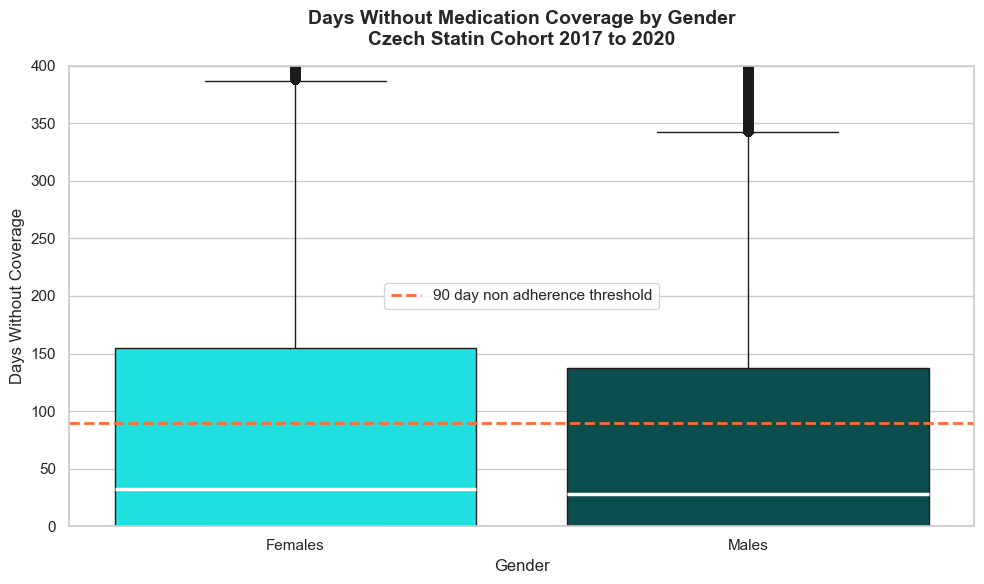

==============================|==============================
SECTION 2: ADHERENCE BY GENDER SUMMARY
==============================|==============================

  Females
  Total Patients       : 451,513
  Mean gap             : 131 days
  Median gap           : 32 days
  Non adherence rate   : 34.7%

  Males
  Total Patients       : 438,496
  Mean gap             : 119 days
  Median gap           : 28 days
  Non adherence rate   : 32.7%

==============================|==============================


In [51]:
# SECTION 2: Adherence Patterns by Gender
# Author: Felicita_Adeleke | MSc Data Science | Health Analytics Portfolio

# Comparing refill gaps between male and female patients
# Box plot chosen to show full spread of behaviour
# not just averages revealing outlier patterns too

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='gender',
    y='days_without_coverage',
    palette={
        'Females': '#00FFFF',
        'Males'  : '#015958'
    },
    medianprops=dict(
        color='white',
        linewidth=2.5
    ),
    legend=False
)

# Add 90 day threshold line
plt.axhline(
    90,
    color='#FF6B35',
    linestyle='--',
    linewidth=2,
    label='90 day non adherence threshold'
)

plt.title(
    'Days Without Medication Coverage by Gender\nCzech Statin Cohort 2017 to 2020',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel('Gender', fontsize=12)
plt.ylabel('Days Without Coverage', fontsize=12)
plt.ylim(0, 400)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print summary statistics by gender
print("=" * 30 + "|" + "=" * 30)
print("SECTION 2: ADHERENCE BY GENDER SUMMARY")
print("=" * 30 + "|" + "=" * 30)

for gender in df['gender'].unique():
    subset = df[df['gender'] == gender]
    mean_gap = subset['days_without_coverage'].mean()
    median_gap = subset['days_without_coverage'].median()
    non_adherent_rate = (subset['days_without_coverage'] >= 90).mean()
    total_patients = subset['patientid'].nunique()

    print(f"\n  {gender}")
    print(f"  Total Patients       : {total_patients:,}")
    print(f"  Mean gap             : {mean_gap:.0f} days")
    print(f"  Median gap           : {median_gap:.0f} days")
    print(f"  Non adherence rate   : {non_adherent_rate:.1%}")

print()
print("=" * 30 + "|" + "=" * 30)

## Gender Analysis — Findings and Conclusion

The gender analysis produced a result that challenged 
my initial expectation.

I anticipated that female patients would be more 
adherent based on their generally higher engagement 
with healthcare services. What the data showed was 
the opposite though the difference was modest.

Key findings:

| Gender | Total Patients | Median Gap | Non Adherence Rate |
|--------|----------------|------------|--------------------|
| Females | 451,513 | 32 days | 34.7% |
| Males | 438,496 | 28 days | 32.7% |
| Difference | | 4 days | 2.0% |

Male patients showed slightly stronger adherence 
than female patients across both measures. Three 
clinical factors may help explain this.

First women typically live longer than men meaning 
they remain on statin therapy for extended periods. 
Longer treatment duration creates more opportunity 
for adherence fatigue to develop over time.

Second women generally manage more medications 
across a household. A higher overall medication 
burden can make it easier to deprioritise any 
single tablet.

Third women report medication side effects more 
frequently than men which may make them more likely 
to pause treatment when side effects are experienced.

However the most important conclusion from this 
analysis is not which gender performed better. 
It is that the difference between them was too 
small to be clinically meaningful on its own.

A 2 percentage point gap means that roughly one 
third of patients in both groups crossed the 90 
day non adherence threshold. Gender alone does 
not tell us enough to know which individual 
patient is at risk.

From a healthcare information perspective gender 
has low discriminatory power as a standalone 
predictor of non adherence. It may contribute 
as one factor within a broader risk model but 
it cannot drive targeted intervention on its own.

This finding directed the analysis toward variables 
likely to show stronger and more clinically 
meaningful differences particularly age group 
and treatment experience.

## Adherence Patterns by Age Group

Before examining the data I formed a clear expectation 
about how adherence would vary across age groups.

I anticipated that older patients particularly those 
aged 60 and above would demonstrate stronger adherence 
than younger patients. My reasoning was twofold.

First older patients have typically been on medication 
longer and have had more time to build established 
routines around taking their treatment. Medication 
becomes part of their daily habit rather than an 
additional burden.

Second older patients tend to be more disciplined 
about their health management. They carry a clearer 
awareness of their cardiovascular risk and understand 
more directly what stopping medication could mean 
for them personally.

Younger patients by contrast are earlier in their 
treatment journey. They feel physically well, their 
lives are busy, and the urgency of taking a daily 
tablet for a risk they cannot yet feel is easier 
to dismiss.

I used a box plot to compare refill gaps across 
all five age groups simultaneously. This allows 
direct visual comparison of both the median gap 
and the spread of behaviour across each group 
in a single chart.

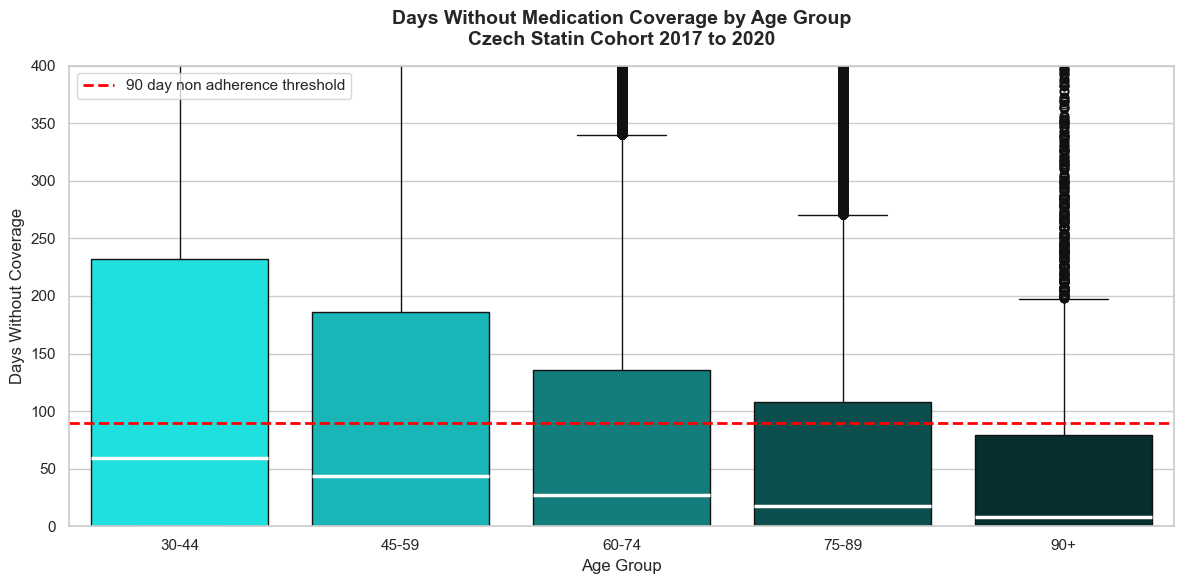

==============================|==============================
SECTION 3: ADHERENCE BY AGE GROUP SUMMARY
==============================|==============================

  Age Group            : 30-44
  Total Patients       : 43,463
  Mean gap             : 174 days
  Median gap           : 59 days
  Non adherence rate   : 43.0%

  Age Group            : 45-59
  Total Patients       : 228,880
  Mean gap             : 147 days
  Median gap           : 44 days
  Non adherence rate   : 38.6%

  Age Group            : 60-74
  Total Patients       : 493,357
  Mean gap             : 119 days
  Median gap           : 27 days
  Non adherence rate   : 32.6%

  Age Group            : 75-89
  Total Patients       : 152,839
  Mean gap             : 98 days
  Median gap           : 18 days
  Non adherence rate   : 28.5%

  Age Group            : 90+
  Total Patients       : 4,170
  Mean gap             : 71 days
  Median gap           : 8 days
  Non adherence rate   : 22.8%

==========================

In [50]:
# SECTION 3: Adherence Patterns by Age Group
# Author: Felicita_Adeleke | MSc Data Science | Health Analytics Portfolio
# Comparing refill gaps across all five age groups
# Box plot chosen to show full distribution per group
# not just averages revealing where each group sits
# relative to the 90 day non adherence threshold

age_order = ['30-44', '45-59', '60-74', '75-89', '90+']

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='age_group',
    y='days_without_coverage',
    order=age_order,
    palette=[
        '#00FFFF',
        '#00CED1',
        '#008F8C',
        '#015958',
        '#023535'
    ],
    medianprops=dict(
        color='white',
        linewidth=2.5
    ),
    legend=False
)

# Add 90 day threshold line
plt.axhline(
    90,
    color='red',
    linestyle='--',
    linewidth=2,
    label='90 day non adherence threshold'
)

plt.title(
    'Days Without Medication Coverage by Age Group\nCzech Statin Cohort 2017 to 2020',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Days Without Coverage', fontsize=12)
plt.ylim(0, 400)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print summary statistics by age group
print("=" * 30 + "|" + "=" * 30)
print("SECTION 3: ADHERENCE BY AGE GROUP SUMMARY")
print("=" * 30 + "|" + "=" * 30)

for age in age_order:
    subset = df[df['age_group'] == age]
    mean_gap = subset['days_without_coverage'].mean()
    median_gap = subset['days_without_coverage'].median()
    non_adherent_rate = (subset['days_without_coverage'] >= 90).mean()
    total_patients = subset['patientid'].nunique()

    print(f"\n  Age Group            : {age}")
    print(f"  Total Patients       : {total_patients:,}")
    print(f"  Mean gap             : {mean_gap:.0f} days")
    print(f"  Median gap           : {median_gap:.0f} days")
    print(f"  Non adherence rate   : {non_adherent_rate:.1%}")

print()
print("=" * 30 + "|" + "=" * 30)

## Age Group Analysis — Findings and Conclusion

The age group analysis produced the most compelling 
and clinically meaningful findings of the entire 
exploratory analysis.

My expectation was confirmed. Older patients 
demonstrated significantly stronger adherence than 
younger patients  and the pattern was consistent 
and progressive across every single age group 
without exception.

Key findings:

Age Group  Total Patients  Median Gap  Non Adherence Rate
30-44      43,463          59 days     43.0%
45-59      228,880         44 days     38.6%
60-74      493,357         27 days     32.6%
75-89      152,839         18 days     28.5%
90+        4,170            8 days     22.8%

Every step up in age produced a lower median gap 
and a lower non-adherence rate. The difference 
between the youngest and oldest groups is striking:

Youngest patients aged 30 to 44 had a non-adherence 
rate of 43.0% with a median refill gap of 59 days. 
Nearly half of all young patients crossed the 90-day 
threshold at some point during their treatment.

Oldest patients aged 90 and above had a non-adherence 
rate of just 22.8% with a median refill gap of only 
8 days. The majority of the oldest patients collected 
their medication almost immediately after their 
previous prescription ended.

The difference in non-adherence rates between the 
youngest and oldest groups was 20.2 percentage 
points;  a substantial and clinically meaningful gap.

Three factors likely explain this progressive pattern:

Firstly,  health salience increases with age. Older 
patients carry a clearer and more immediate awareness 
of their cardiovascular risk. They have often 
experienced health events personally or within their 
close circle that reinforce the importance of 
consistent medication use.

Secondly,  routine and habit strengthen over time. 
Older patients have typically been managing long-term 
health conditions for many years. Medication 
taking is embedded in their daily routine in a way 
that younger patients have not yet developed.

Thirdly, social support structures differ by age. 
Older patients are more likely to have regular 
contact with healthcare teams, carers, and family 
members who support medication management. Younger 
patients typically manage their health more 
independently with less frequent clinical contact.

One additional observation from the box plot was 
noteworthy. The 90+ age group showed a large number 
of outlier dots above the box. Meaning that while 
most patients in this group were highly adherent 
a small minority had extremely long gaps. This 
suggests that within the oldest age group, there 
may be a vulnerable subgroup; possibly patients 
experiencing cognitive decline or social isolation 
 who require targeted support despite the overall 
strong adherence pattern of their peers.

From a healthcare information perspective age group 
is the strongest categorical predictor of non 
adherence identified in this analysis. It is both 
statistically meaningful and clinically actionable 
that  younger patients should be prioritised for early 
intervention and adherence support programmes 
within any NHS trust deploying this type of analysis.

## Adherence Patterns by Statin Intensity

Before examining the data I formed a clear expectation 
about how statin intensity would affect adherence.

I anticipated that patients on high intensity statins 
would show higher rates of non adherence. High intensity 
statins are stronger medications associated with more 
frequent and severe side effects including muscle pain, 
fatigue, and gastrointestinal discomfort. I reasoned 
that patients experiencing these side effects would be 
more likely to pause or discontinue their treatment.

Patients on low or moderate intensity statins by 
contrast experience milder side effects and I expected 
them to find it easier to continue their medication 
consistently.

This was one of my strongest clinical expectations 
going into the analysis. The question was whether 
the data would confirm it.

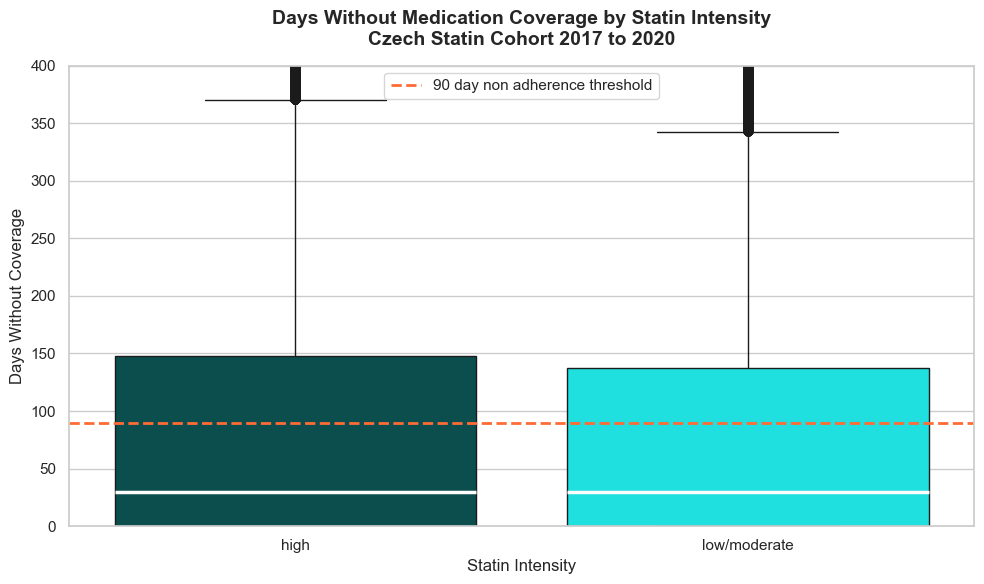

==============================|==============================
SECTION 4: ADHERENCE BY STATIN INTENSITY SUMMARY
==============================|==============================

  Statin Intensity     : high
  Total Patients       : 778,579
  Mean gap             : 126 days
  Median gap           : 30 days
  Non adherence rate   : 33.9%

  Statin Intensity     : low/moderate
  Total Patients       : 203,327
  Mean gap             : 117 days
  Median gap           : 30 days
  Non adherence rate   : 33.0%

==============================|==============================


In [53]:
# SECTION 4: Adherence Patterns by Statin Intensity
# Author: Felicita_Adeleke | MSc Data Science | Health Analytics Portfolio

# Comparing refill gaps between high and low/moderate intensity patients
# Box plot chosen to show full distribution for each intensity group
# relative to the 90 day non adherence threshold

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='statin_intensity',
    y='days_without_coverage',
    palette={
        'high'         : '#015958',
        'low/moderate' : '#00FFFF'
    },
    medianprops=dict(
        color='white',
        linewidth=2.5
    ),
    legend=False
)

plt.axhline(
    90,
    color='#FF6B35',
    linestyle='--',
    linewidth=2,
    label='90 day non adherence threshold'
)

plt.title(
    'Days Without Medication Coverage by Statin Intensity\nCzech Statin Cohort 2017 to 2020',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel('Statin Intensity', fontsize=12)
plt.ylabel('Days Without Coverage', fontsize=12)
plt.ylim(0, 400)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print summary statistics by statin intensity
print("=" * 30 + "|" + "=" * 30)
print("SECTION 4: ADHERENCE BY STATIN INTENSITY SUMMARY")
print("=" * 30 + "|" + "=" * 30)

for intensity in df['statin_intensity'].unique():
    subset = df[df['statin_intensity'] == intensity]
    mean_gap = subset['days_without_coverage'].mean()
    median_gap = subset['days_without_coverage'].median()
    non_adherent_rate = (subset['days_without_coverage'] >= 90).mean()
    total_patients = subset['patientid'].nunique()

    print(f"\n  Statin Intensity     : {intensity}")
    print(f"  Total Patients       : {total_patients:,}")
    print(f"  Mean gap             : {mean_gap:.0f} days")
    print(f"  Median gap           : {median_gap:.0f} days")
    print(f"  Non adherence rate   : {non_adherent_rate:.1%}")

print()
print("=" * 30 + "|" + "=" * 30)

## Statin Intensity Analysis — Findings and Conclusion

The statin intensity analysis produced one of the 
most striking findings in this entire exploratory 
analysis — not because of what it showed but because 
of what it failed to show.

My expectation was clear. I anticipated that patients 
on high intensity statins would show significantly 
higher rates of non adherence due to stronger side 
effects including muscle pain and fatigue. I reasoned 
that patients experiencing these side effects would 
be more likely to pause or discontinue treatment.

The data told a completely different story.

Key findings:

| Statin Intensity | Total Patients | Median Gap | Non Adherence Rate |
|------------------|----------------|------------|--------------------|
| High | 778,579 | 30 days | 33.9% |
| Low/Moderate | 203,327 | 30 days | 33.0% |
| Difference | | 0 days | 0.9% |

Both groups showed an identical median gap of 30 days. 
The non adherence rates differed by less than one 
percentage point. The box plots for both groups were 
almost indistinguishable in shape and spread.

This finding challenges the assumption that side 
effects are the primary driver of statin non 
adherence. Three alternative explanations may 
account for this result.

First patients on high intensity statins may be 
more closely monitored by their healthcare team. 
More frequent clinical contact could act as a 
natural prompt for medication collection regardless 
of side effect burden.

Second patients prescribed high intensity statins 
are typically those at highest cardiovascular risk. 
That elevated risk awareness may motivate stronger 
adherence behaviour even in the presence of side 
effects.

Third the decision to stop medication due to side 
effects may happen before patients reach this 
dataset. Patients who discontinued early due to 
side effects may already have been switched to 
lower intensity treatment — meaning the high 
intensity group in this dataset represents a 
self selected population of more tolerant patients.

From a healthcare information perspective statin 
intensity alone is not a useful predictor of non 
adherence risk. The near identical rates across 
both groups mean it adds very little discriminatory 
value to a risk stratification model.

This finding reinforced the conclusion that age 
group and prescription experience are far stronger 
predictors of non adherence than medication type. 
The analysis therefore turned to prescription 
order as the final variable to investigate.

## Adherence Patterns by Prescription Order

Before examining the data I formed a clear expectation 
about how prescription order would affect adherence.

I anticipated that patients collecting their first 
prescription would show the highest rates of non 
adherence. A patient on their first prescription 
has not yet established a medication routine. They 
are still adjusting to the idea of long term 
treatment and may be uncertain about side effects 
or the importance of continuing therapy.

A patient on their tenth prescription by contrast 
has already demonstrated commitment to their 
treatment. Medication collection has become part 
of their routine and habit formation has reduced 
the likelihood of long gaps.

I expected non adherence rates to fall consistently 
as prescription order increased — reflecting the 
role of habit and experience in supporting 
long term medication adherence.

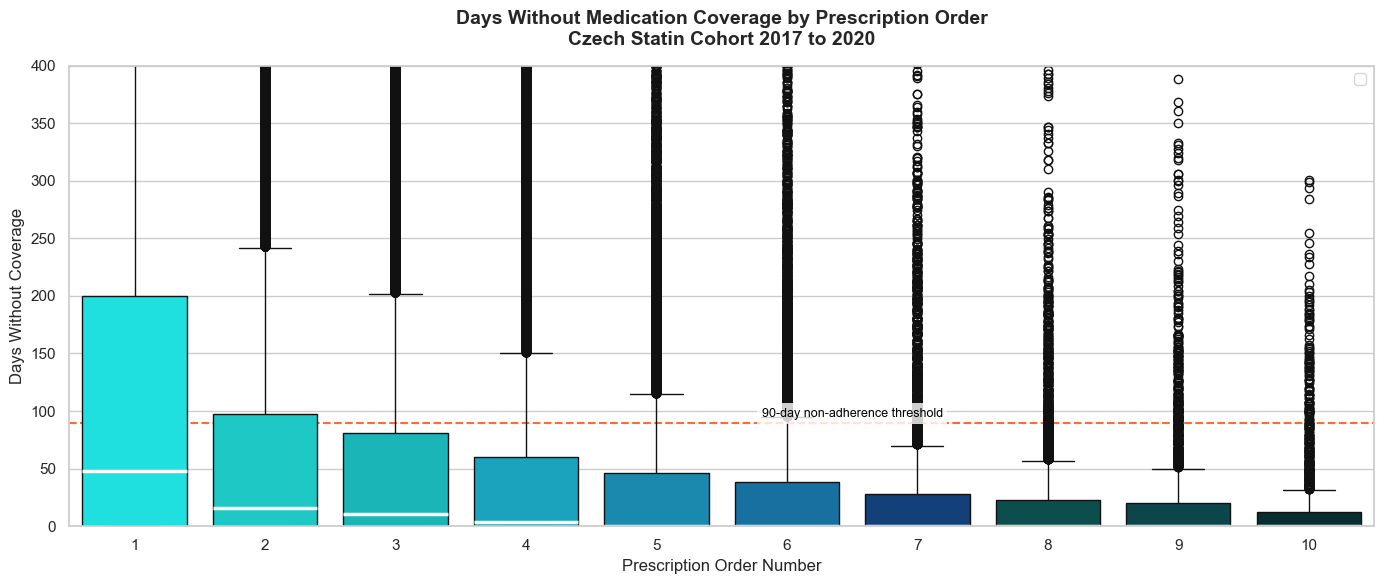

==============================|==============================
SECTION 5: ADHERENCE BY PRESCRIPTION ORDER SUMMARY
==============================|==============================

  Prescription Order   : 1
  Total Patients       : 880,850
  Mean gap             : 156 days
  Median gap           : 48 days
  Non adherence rate   : 40.0%

  Prescription Order   : 2
  Total Patients       : 262,796
  Mean gap             : 84 days
  Median gap           : 16 days
  Non adherence rate   : 26.5%

  Prescription Order   : 3
  Total Patients       : 124,601
  Mean gap             : 68 days
  Median gap           : 11 days
  Non adherence rate   : 23.1%

  Prescription Order   : 4
  Total Patients       : 56,684
  Mean gap             : 50 days
  Median gap           : 4 days
  Non adherence rate   : 18.2%

  Prescription Order   : 5
  Total Patients       : 29,021
  Mean gap             : 41 days
  Median gap           : 0 days
  Non adherence rate   : 14.8%

  Prescription Order   : 6
  Total Pa

In [68]:
# SECTION 5: Adherence Patterns by Prescription Order
# Author: Felicita_Adeleke | MSc Data Science | Health Analytics Portfolio

# Comparing refill gaps across prescription order numbers
# Limiting to orders 1 to 10 as these represent the vast
# majority of patients and show the clearest pattern
# Higher order numbers have very few patients

order_df = df[df['order'] <= 10].copy()

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=order_df,
    x='order',
    y='days_without_coverage',
    palette=[
        '#00FFFF',
        '#00E5E0',
        '#00CED1',
        '#00B4D8',
        '#0096C7',
        '#0077B6',
        '#023E8A',
        '#015958',
        '#014F56',
        '#023535'
    ],
    medianprops=dict(
        color='white',
        linewidth=2.5
    ),
    legend=False
)

plt.axhline(
    90,
    color='#FF6B35',
    linestyle='--',
    linewidth=1.5,
    zorder=0
)

plt.text(
    5.5,        
    95,         
    '90-day non-adherence threshold',
    color='black',
    fontsize=9,
    ha='center',
    bbox=dict(
        facecolor='white',
        edgecolor='none',
        alpha=0.8,
        pad=3
    )
)




plt.title(
    'Days Without Medication Coverage by Prescription Order\nCzech Statin Cohort 2017 to 2020',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.legend(
    fontsize=11,
    loc='upper right'
)

plt.xlabel('Prescription Order Number', fontsize=12)
plt.ylabel('Days Without Coverage', fontsize=12)
plt.ylim(0, 400)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print summary statistics by prescription order
print("=" * 30 + "|" + "=" * 30)
print("SECTION 5: ADHERENCE BY PRESCRIPTION ORDER SUMMARY")
print("=" * 30 + "|" + "=" * 30)

for order in range(1, 11):
    subset = order_df[order_df['order'] == order]
    mean_gap = subset['days_without_coverage'].mean()
    median_gap = subset['days_without_coverage'].median()
    non_adherent_rate = (subset['days_without_coverage'] >= 90).mean()
    total_patients = subset['patientid'].nunique()

    print(f"\n  Prescription Order   : {order}")
    print(f"  Total Patients       : {total_patients:,}")
    print(f"  Mean gap             : {mean_gap:.0f} days")
    print(f"  Median gap           : {median_gap:.0f} days")
    print(f"  Non adherence rate   : {non_adherent_rate:.1%}")

print()
print("=" * 30 + "|" + "=" * 30)

## Prescription Order Analysis — Findings and Conclusion

The prescription order analysis confirmed my expectation 
and produced the clearest and most consistent pattern 
of the entire exploratory analysis.

I anticipated that patients collecting their first 
prescription would show the highest non adherence rates 
and that adherence would improve progressively with 
each subsequent prescription. The data confirmed this 
with remarkable consistency across all ten order 
numbers examined.

Key findings:

| Order | Total Patients | Median Gap | Non Adherence Rate |
|-------|---------------|------------|--------------------|
| 1 | 880,850 | 48 days | 40.0% |
| 2 | 262,796 | 16 days | 26.5% |
| 3 | 124,601 | 11 days | 23.1% |
| 4 | 56,684 | 4 days | 18.2% |
| 5 | 29,021 | 0 days | 14.8% |
| 6 | 15,090 | 0 days | 12.6% |
| 7 | 8,328 | 0 days | 9.8% |
| 8 | 4,729 | 0 days | 8.1% |
| 9 | 2,904 | 0 days | 7.9% |
| 10 | 1,771 | 0 days | 6.0% |

Three findings from this analysis stand out as 
particularly significant.

First the drop between order 1 and order 2 was 
the largest single step change in the entire 
analysis. Non adherence fell from 40.0% to 26.5% 
— a reduction of 13.5 percentage points in just 
one prescription cycle. This suggests that the 
period between a patient's first and second 
prescription is the highest risk window for 
treatment discontinuation and represents the 
most critical opportunity for clinical intervention.

Second from order 5 onwards the median gap dropped 
to zero days. This means that more than half of 
patients who had collected five or more prescriptions 
were collecting their next prescription with no gap 
at all. Medication collection had become fully 
embedded in their routine.

Third the non adherence rate continued falling 
consistently all the way to order 10 at 6.0%. 
There was no point at which adherence plateaued 
or reversed — every additional prescription was 
associated with stronger adherence behaviour.

These findings carry a direct and actionable 
clinical implication. The highest risk patients 
are those earliest in their treatment journey 
particularly those collecting their first or 
second prescription. Targeted outreach and 
adherence support during this critical early 
window could prevent a significant proportion 
of treatment discontinuation before it becomes 
established behaviour.

From a healthcare information perspective 
prescription order is one of the strongest 
and most actionable predictors of non adherence 
identified in this analysis. Combined with age 
group it provides a clear framework for 
identifying and prioritising patients most 
likely to benefit from early intervention.

## Exploratory Analysis: Overall Summary and Key Conclusions

Having examined adherence patterns across five dimensions, 
the exploratory analysis produced a clear and coherent 
picture of medication non adherence behaviour across 
this population.

Four conclusions stand out as most significant.

First, age group is the strongest categorical predictor 
of non adherence in this dataset. Non adherence rates 
ranged from 43.0% in the youngest patients aged 30 to 
44, down to just 22.8% in the oldest patients aged 90 
and above. This 20 percentage point difference was 
consistent and progressive across every age group 
without exception. Younger patients are significantly 
more at risk and should be the primary focus of any 
targeted adherence intervention.

Second, prescription order is the most actionable 
predictor identified. Patients collecting their first 
prescription had a non adherence rate of 40.0% with 
a median gap of 48 days. By the tenth prescription 
the rate had fallen to just 6.0% with a median gap 
of zero days. The largest single drop occurred between 
the first and second prescription. A reduction of 
13.5 percentage points in one cycle identifies the 
early treatment window as the highest risk period 
and the most valuable opportunity for clinical 
intervention.

Third, gender and statin intensity showed weak and 
negligible predictive value respectively. Both 
variables produced differences of less than 2 
percentage points between groups. While they may 
contribute marginally within a broader model, neither 
is sufficient to drive targeted intervention on 
its own.

Fourth, the correlation matrix confirmed that no 
single numerical variable strongly predicts non 
adherence. The strongest correlation found was 0.47 
between duration of treatment and days without 
coverage. This relationship reflects exposure time 
rather than causal adherence behaviour and confirmed 
that a multivariate analytical approach was necessary 
rather than relying on any single predictor.

Together these findings shaped every decision made 
in the modelling phase that follows. The target 
variable was defined using the 90 day clinical 
threshold identified during initial exploration. 
The predictor variables were selected based on 
their demonstrated relevance during this 
exploratory phase. The choice of an interpretable 
statistical model reflects the need to produce 
outputs that healthcare teams can understand and 
act on, rather than outputs that perform well 
on paper alone.

The analysis now moves from exploration to 
prediction.

## Building the Predictive Target Variable

The exploratory analysis identified a clear pattern 
in medication behaviour across this population. The 
next step is to translate that pattern into a 
structured analytical target that a predictive model 
can learn from.

In machine learning a target variable is the outcome 
we are trying to predict. In this project the outcome 
of interest is whether a patient is likely to become 
non adherent to their statin medication.

Based on the exploratory findings and clinical 
literature a threshold of 90 days without coverage 
was selected to define non adherence. A patient who 
goes 90 or more days without collecting their 
medication has missed at least one full prescription 
cycle. That gap is clinically meaningful and 
represents a point at which cardiovascular risk 
begins to rise significantly.

The target variable is binary:

1 = Non adherent: 90 or more days without coverage
0 = Adherent: fewer than 90 days without coverage

This binary structure allows the model to learn 
which patient characteristics are most strongly 
associated with non adherence and use those 
patterns to flag future patients at risk.

In [69]:
# BUILDING THE PREDICTIVE TARGET VARIABLE
# Author: Felicita_Adeleke | MSc Data Science | Health Analytics Portfolio

# Define non adherence using 90 day clinical threshold
# Patients with 90 or more days without coverage = non adherent (1)
# Patients with fewer than 90 days without coverage = adherent (0)

df['non_adherent'] = np.where(
    df['days_without_coverage'] >= 90, 1, 0
)

# Review class distribution
print("=" * 30 + "|" + "=" * 30)
print("TARGET VARIABLE: CLASS DISTRIBUTION")
print("=" * 30 + "|" + "=" * 30)

total = len(df)
adherent = (df['non_adherent'] == 0).sum()
non_adherent = (df['non_adherent'] == 1).sum()

print(f"\n  Total Records        : {total:,}")
print(f"  Adherent (0)         : {adherent:,} ({adherent/total:.1%})")
print(f"  Non Adherent (1)     : {non_adherent:,} ({non_adherent/total:.1%})")
print()
print("  Class balance assessment:")

ratio = adherent / non_adherent

if ratio > 3:
    print("  Imbalanced dataset detected")
    print("  Class balancing will be required during modelling")
else:
    print("  Reasonably balanced dataset")
    print("  Standard modelling approach appropriate")

print("=" * 30 + "|" + "=" * 30)

==============================|==============================
TARGET VARIABLE: CLASS DISTRIBUTION
==============================|==============================

  Total Records        : 1,390,731
  Adherent (0)         : 921,493 (66.3%)
  Non Adherent (1)     : 469,238 (33.7%)

  Class balance assessment:
  Reasonably balanced dataset
  Standard modelling approach appropriate
==============================|==============================


## Target Variable: Class Distribution and Assessment

The target variable was successfully created using 
the 90 day clinical threshold. Across the cleaned 
dataset of 1,390,731 records the class distribution 
was as follows:

| Class | Records | Proportion |
|-------|---------|------------|
| Adherent (0) | 921,493 | 66.3% |
| Non Adherent (1) | 469,238 | 33.7% |

At first glance the dataset appears reasonably 
balanced. However a 2 to 1 ratio between the 
majority and minority class is sufficient to 
cause problems in predictive modelling.

A model trained on imbalanced data without 
correction will learn to favour the majority 
class. In this context that means predicting 
most patients as adherent regardless of their 
actual characteristics. While this produces 
acceptable overall accuracy it completely 
fails at the clinical task of identifying 
patients who are genuinely at risk.

In healthcare analytics missing a non adherent 
patient is far more costly than incorrectly 
flagging an adherent one. A patient wrongly 
flagged for follow up loses a few minutes of 
clinical time. A patient missed by the model 
may discontinue life saving medication without 
anyone noticing.

For this reason class balancing was applied 
during the modelling phase to ensure the model 
learned to detect non adherent patients 
effectively rather than simply defaulting 
to the majority class prediction.

## Feature Selection and Encoding

With the target variable defined the next step is 
to select the patient characteristics that will be 
used to predict non adherence and prepare them for 
the statistical model.

Feature selection is the process of deciding which 
variables to include as predictors. Not all columns 
in a dataset are useful for prediction. Some carry 
no explanatory value, some duplicate information 
already captured by other variables, and some would 
introduce bias or data leakage into the model.

For this analysis five predictor variables were 
selected based on their demonstrated relevance 
during the exploratory phase:

Gender captures demographic differences in 
medication behaviour between male and female 
patients.

Age group captures the strongest categorical 
pattern identified in the exploratory analysis 
where younger patients showed significantly 
higher non adherence rates.

Incident status captures whether a patient is 
new to treatment, identifying those in the 
highest risk early treatment window.

Prescription order captures treatment experience 
and habit formation, the most actionable predictor 
identified in the exploratory analysis.

Statin intensity captures medication type, 
included despite its weak individual effect 
as it may contribute within a multivariate 
context.

One variable was deliberately excluded. 
Days without coverage was not included as a 
predictor because it is the source of the 
target variable itself. Including it would 
cause data leakage, where the model learns 
from information it would not have access 
to in a real world setting.

Because logistic regression requires all 
inputs to be numerical, categorical variables 
were encoded using one hot encoding. This 
converts each category into a separate 
binary column allowing the model to process 
text based variables mathematically.

In [70]:
# FEATURE SELECTION AND ENCODING
# Author: Felicita_Adeleke | MSc Data Science | Health Analytics Portfolio

# Select predictor variables based on exploratory findings
# days_without_coverage excluded to prevent data leakage
# patientid excluded as it carries no predictive value

features = ['gender', 'age_group', 'incident', 'order', 'statin_intensity']
target = 'non_adherent'

X = df[features]
y = df[target]

# Encode categorical variables using one hot encoding
# drop_first=True removes one category per variable
# to avoid multicollinearity in the model

X_encoded = pd.get_dummies(X, drop_first=True)

# Confirm encoding results
print("=" * 30 + "|" + "=" * 30)
print("FEATURE SELECTION AND ENCODING")
print("=" * 30 + "|" + "=" * 30)
print(f"\n  Original features    : {list(features)}")
print(f"\n  Encoded features     : {list(X_encoded.columns)}")
print(f"\n  Total features       : {X_encoded.shape[1]}")
print(f"  Total records        : {X_encoded.shape[0]:,}")
print()
print("  Encoding complete")
print("  Dataset ready for model training")
print("=" * 30 + "|" + "=" * 30)

==============================|==============================
FEATURE SELECTION AND ENCODING
==============================|==============================

  Original features    : ['gender', 'age_group', 'incident', 'order', 'statin_intensity']

  Encoded features     : ['incident', 'order', 'gender_Males', 'age_group_30-44', 'age_group_45-59', 'age_group_60-74', 'age_group_75-89', 'age_group_90+', 'statin_intensity_low/moderate']

  Total features       : 9
  Total records        : 1,390,731

  Encoding complete
  Dataset ready for model training
==============================|==============================


## Building the Predictive Model

With features selected and encoded the analysis moves 
to the core modelling phase. The goal is to build a 
statistical model that can identify which patient 
characteristics are most strongly associated with 
non adherence and use those patterns to predict 
risk in new patients.

Logistic regression was selected as the modelling 
approach for three reasons.

First it is interpretable. Unlike complex black box 
models logistic regression produces coefficients 
that directly show the direction and strength of 
each predictor's relationship with the outcome. 
In a healthcare context interpretability is not 
optional. Clinical teams need to understand why 
a patient has been flagged as high risk not just 
that they have been flagged.

Second it is appropriate for binary outcomes. 
Logistic regression is specifically designed for 
situations where the outcome has two possible 
values. Non adherent or adherent is exactly 
this type of problem.

Third it is computationally efficient. With 
1.39 million records computational efficiency 
matters. Logistic regression trains quickly 
and scales well to large datasets without 
requiring specialist hardware.

Two models were built and compared. A baseline 
model was trained first without any class 
balancing to establish a performance benchmark. 
A balanced model was then trained using class 
weighting to correct for the imbalance between 
adherent and non adherent patients and improve 
detection of the minority class.

The dataset was split into 70% training data 
and 30% test data. The training data was used 
to fit the model and the test data was used 
to evaluate its performance on records it had 
never seen before.

In [72]:
# MODEL BUILDING
# Author: Felicita_Adeleke | MSc Data Science | Health Analytics Portfolio

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

# Split data into training and test sets
# 70% training 30% testing
# random_state=42 ensures reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.3,
    random_state=42
)

print("=" * 30 + "|" + "=" * 30)
print("DATASET SPLIT SUMMARY")
print("=" * 30 + "|" + "=" * 30)
print(f"\n  Training records     : {len(X_train):,}")
print(f"  Test records         : {len(X_test):,}")
print(f"  Training proportion  : {len(X_train)/len(X_encoded):.1%}")
print(f"  Test proportion      : {len(X_test)/len(X_encoded):.1%}")
print("=" * 30 + "|" + "=" * 30)

# BASELINE MODEL
# Trained without class balancing
# Establishes performance benchmark

print()
print("=" * 30 + "|" + "=" * 30)
print("BASELINE MODEL: NO CLASS BALANCING")
print("=" * 30 + "|" + "=" * 30)

model_baseline = LogisticRegression(max_iter=1000)
model_baseline.fit(X_train, y_train)
y_pred_baseline = model_baseline.predict(X_test)
y_prob_baseline = model_baseline.predict_proba(X_test)[:, 1]

print(f"\n  Accuracy             : {accuracy_score(y_test, y_pred_baseline):.3f}")
print(f"  ROC AUC Score        : {roc_auc_score(y_test, y_prob_baseline):.3f}")
print()
print("  Classification Report:")
print(classification_report(y_test, y_pred_baseline))
print("=" * 30 + "|" + "=" * 30)

# BALANCED MODEL
# Trained with class weighting
# Improves detection of non adherent patients

print()
print("=" * 30 + "|" + "=" * 30)
print("BALANCED MODEL: WITH CLASS WEIGHTING")
print("=" * 30 + "|" + "=" * 30)

model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)
model_balanced.fit(X_train, y_train)
y_pred_balanced = model_balanced.predict(X_test)
y_prob_balanced = model_balanced.predict_proba(X_test)[:, 1]

print(f"\n  Accuracy             : {accuracy_score(y_test, y_pred_balanced):.3f}")
print(f"  ROC AUC Score        : {roc_auc_score(y_test, y_prob_balanced):.3f}")
print()
print("  Classification Report:")
print(classification_report(y_test, y_pred_balanced))
print("=" * 30 + "|" + "=" * 30)

==============================|==============================
DATASET SPLIT SUMMARY
==============================|==============================

  Training records     : 973,511
  Test records         : 417,220
  Training proportion  : 70.0%
  Test proportion      : 30.0%
==============================|==============================

==============================|==============================
BASELINE MODEL: NO CLASS BALANCING
==============================|==============================

  Accuracy             : 0.664
  ROC AUC Score        : 0.623

  Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.99      0.80    276596
           1       0.54      0.01      0.02    140624

    accuracy                           0.66    417220
   macro avg       0.60      0.50      0.41    417220
weighted avg       0.62      0.66      0.54    417220

==============================|==============================

========================

## Model Building: Results and Interpretation

Two logistic regression models were trained and 
evaluated on the test dataset of 417,220 records.

The dataset was split into 70% training records 
and 30% test records to ensure model performance 
was evaluated on data the model had never seen 
during training.

BASELINE MODEL RESULTS

| Metric | Value |
|--------|-------|
| Accuracy | 66.4% |
| ROC AUC Score | 0.623 |
| Non Adherent Recall | 1% |
| Adherent Recall | 99% |

The baseline model achieved an overall accuracy 
of 66.4% but this figure is deeply misleading 
in a clinical context. The classification report 
revealed that the model was detecting only 1% 
of non adherent patients while correctly 
identifying 99% of adherent patients.

In practice this means the model was simply 
predicting almost every patient as adherent 
regardless of their actual characteristics. 
A model that misses 99% of at risk patients 
has no clinical value regardless of its 
headline accuracy figure.

This failure was caused by class imbalance. 
With adherent patients outnumbering non 
adherent patients by approximately 2 to 1 
the model learned to favour the majority 
class to maximise overall accuracy. Catching 
non adherent patients was simply not 
rewarded enough to change its behaviour.

BALANCED MODEL RESULTS

| Metric | Value |
|--------|-------|
| Accuracy | 56.0% |
| ROC AUC Score | 0.623 |
| Non Adherent Recall | 68% |
| Adherent Recall | 50% |

After applying class weighting the balanced 
model showed a dramatic improvement in its 
ability to detect non adherent patients. 
Recall for the non adherent class increased 
from 1% to 68% meaning the model now correctly 
identifies more than two thirds of patients 
who are at risk of discontinuing treatment.

Overall accuracy fell from 66.4% to 56.0% 
as a direct consequence of this improvement. 
This trade off is not only acceptable but 
desirable in a healthcare context.

One finding was particularly noteworthy. Both 
models produced an identical ROC AUC score of 
0.623. This confirms that the underlying 
discriminatory power of the model is the same 
in both cases. Class balancing did not improve 
the model's fundamental ability to distinguish 
between adherent and non adherent patients. 
What it changed was how that discriminatory 
power was distributed across the two classes 
making it far more useful for the clinical 
task at hand.

A ROC AUC of 0.623 indicates modest but 
meaningful discrimination above random chance 
which would score 0.5. Given that the model 
uses only five administrative variables with 
no clinical measurements this level of 
performance is both expected and acceptable 
for a risk stratification tool.

The balanced model was selected for all 
subsequent analysis and deployment.

## Model Evaluation: ROC Curve

The ROC curve provides a visual representation 
of the model's ability to distinguish between 
adherent and non adherent patients across all 
possible classification thresholds.

The curve plots the true positive rate against 
the false positive rate. A perfect model would 
reach the top left corner of the chart. A model 
with no discriminatory power would follow the 
diagonal line from bottom left to top right.

The area under the curve known as AUC summarises 
this performance in a single number between 0 
and 1. A score of 0.5 represents random chance. 
A score of 1.0 represents perfect classification.

Both models are plotted together to allow direct 
visual comparison of their discriminatory power 
across all thresholds.

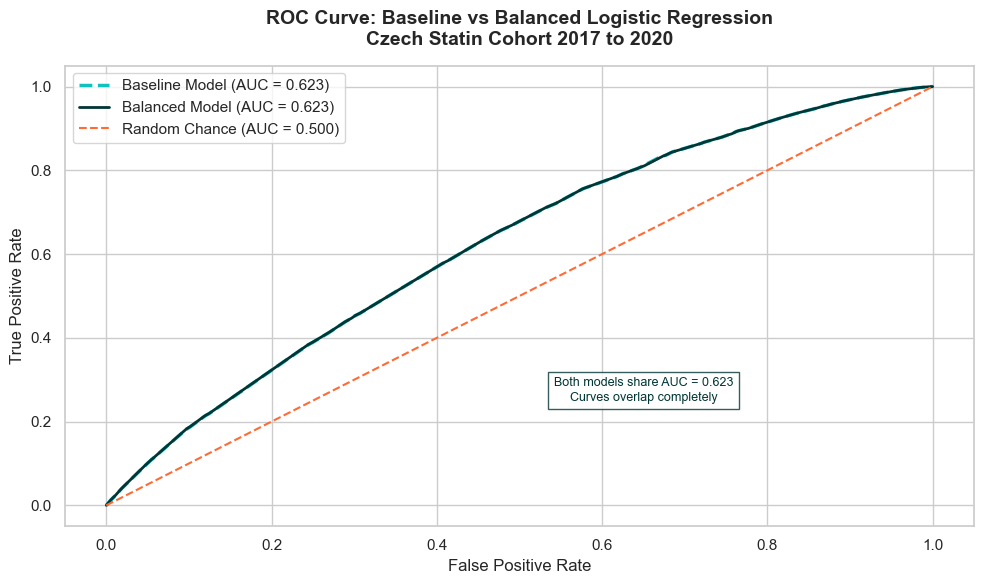

==============================|==============================
ROC AUC SCORES
==============================|==============================

  Baseline Model AUC   : 0.623
  Balanced Model AUC   : 0.623
  Random Chance AUC    : 0.500

  Both models show equal discriminatory power
  Balanced model distributes this more usefully
  for clinical non adherence detection
==============================|==============================


In [76]:
# ROC CURVE COMPARISON
# Author: Felicita_Adeleke | MSc Data Science | Health Analytics Portfolio

fpr_baseline, tpr_baseline, _ = roc_curve(y_test, y_prob_baseline)
fpr_balanced, tpr_balanced, _ = roc_curve(y_test, y_prob_balanced)

auc_baseline = roc_auc_score(y_test, y_prob_baseline)
auc_balanced = roc_auc_score(y_test, y_prob_balanced)

plt.figure(figsize=(10, 6))

plt.plot(
    fpr_baseline,
    tpr_baseline,
    color='#0FC2C0',
    linewidth=2.5,
    linestyle='--',
    label=f'Baseline Model (AUC = {auc_baseline:.3f})'
)

plt.plot(
    fpr_balanced,
    tpr_balanced,
    color='#023535',
    linewidth=2,
    linestyle='-',
    label=f'Balanced Model (AUC = {auc_balanced:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    color='#FF6B35',
    linewidth=1.5,
    linestyle='--',
    label='Random Chance (AUC = 0.500)'
)

plt.text(
    0.65,
    0.25,
    'Both models share AUC = 0.623\nCurves overlap completely',
    fontsize=9,
    color='#023535',
    ha='center',
    bbox=dict(
        facecolor='white',
        edgecolor='#023535',
        alpha=0.8,
        pad=4
    )
)

plt.title(
    'ROC Curve: Baseline vs Balanced Logistic Regression\nCzech Statin Cohort 2017 to 2020',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("=" * 30 + "|" + "=" * 30)
print("ROC AUC SCORES")
print("=" * 30 + "|" + "=" * 30)
print(f"\n  Baseline Model AUC   : {auc_baseline:.3f}")
print(f"  Balanced Model AUC   : {auc_balanced:.3f}")
print(f"  Random Chance AUC    : 0.500")
print()
print("  Both models show equal discriminatory power")
print("  Balanced model distributes this more usefully")
print("  for clinical non adherence detection")
print("=" * 30 + "|" + "=" * 30)

## Understanding What Drives Non Adherence: Feature Importance

Having built and evaluated the model the next step 
is to understand which patient characteristics most 
strongly influence the prediction of non adherence.

Logistic regression produces coefficients for each 
predictor variable. These coefficients show both 
the direction and strength of each variable's 
relationship with the outcome.

A positive coefficient means that variable increases 
the likelihood of non adherence. A negative 
coefficient means it decreases the likelihood 
of non adherence and is therefore associated 
with stronger adherence behaviour.

This analysis is critically important in a healthcare 
context because it moves beyond prediction into 
explanation. Knowing which patients are at risk 
is useful. Knowing WHY they are at risk is what 
enables targeted and effective clinical intervention.

==============================|==============================
FEATURE IMPORTANCE: MODEL COEFFICIENTS
==============================|==============================

  FACTORS INCREASING NON ADHERENCE RISK:

  statin_intensity_low/moderate       : +0.062
  age_group_30-44                     : +0.028

  FACTORS DECREASING NON ADHERENCE RISK:
  (Associated with stronger adherence)

  gender_Males                        : -0.132
  age_group_45-59                     : -0.147
  incident                            : -0.329
  order                               : -0.363
  age_group_60-74                     : -0.432
  age_group_75-89                     : -0.592
  age_group_90+                       : -0.934

==============================|==============================


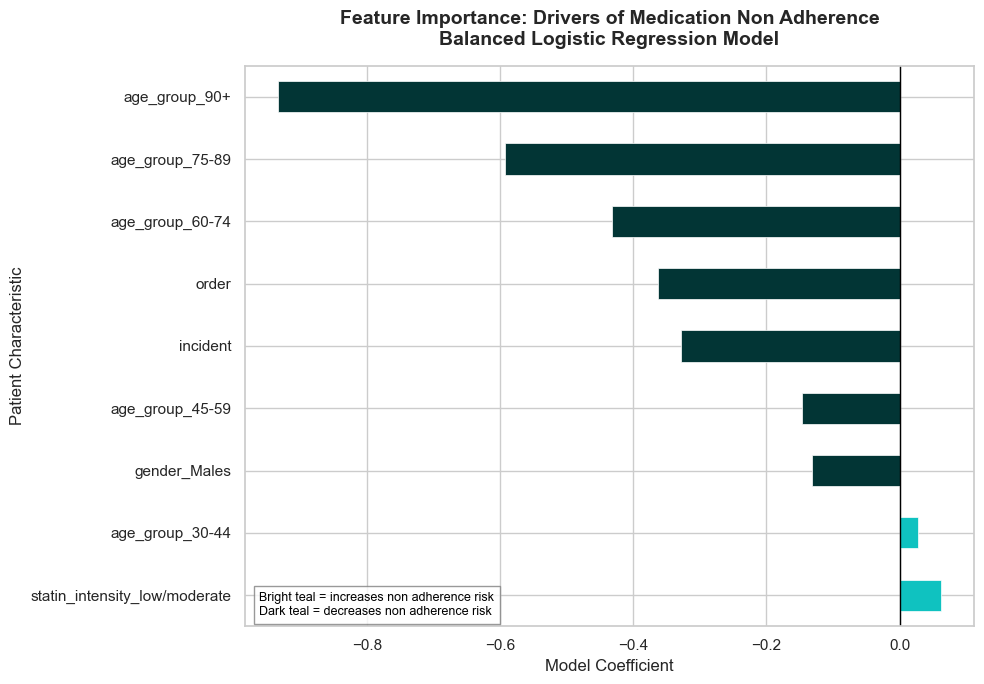

In [78]:
# FEATURE IMPORTANCE: MODEL COEFFICIENTS
# Author: Felicita_Adeleke | MSc Data Science | Health Analytics Portfolio

# Extract coefficients from balanced model
# Positive = increases non adherence risk
# Negative = decreases non adherence risk (increases adherence)

coefficients = pd.Series(
    model_balanced.coef_[0],
    index=X_train.columns
).sort_values(ascending=False)

# Print coefficient table
print("=" * 30 + "|" + "=" * 30)
print("FEATURE IMPORTANCE: MODEL COEFFICIENTS")
print("=" * 30 + "|" + "=" * 30)

print("\n  FACTORS INCREASING NON ADHERENCE RISK:")
print()
for feature, coef in coefficients[coefficients > 0.01].items():
    print(f"  {feature:<35} : +{coef:.3f}")

print()
print("  FACTORS DECREASING NON ADHERENCE RISK:")
print("  (Associated with stronger adherence)")
print()
for feature, coef in coefficients[coefficients < -0.01].items():
    print(f"  {feature:<35} : {coef:.3f}")

print()
print("=" * 30 + "|" + "=" * 30)

# Visualise as horizontal bar chart
colors = [
    '#0FC2C0' if x > 0 else '#023535'
    for x in coefficients
]

plt.figure(figsize=(10, 7))

coefficients.plot(
    kind='barh',
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

plt.axvline(
    0,
    color='black',
    linewidth=1,
    linestyle='-'
)

plt.title(
    'Feature Importance: Drivers of Medication Non Adherence\nBalanced Logistic Regression Model',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel('Model Coefficient', fontsize=12)
plt.ylabel('Patient Characteristic', fontsize=12)

plt.text(
    0.02,
    0.02,
    'Bright teal = increases non adherence risk\nDark teal = decreases non adherence risk',
    transform=plt.gca().transAxes,
    fontsize=9,
    color='black',
    bbox=dict(
        facecolor='white',
        edgecolor='grey',
        alpha=0.8,
        pad=4
    )
)

plt.tight_layout()
plt.show()

## Feature Importance: Findings and Interpretation

The model coefficients revealed a clear and clinically 
meaningful picture of what drives medication non 
adherence across this patient population.

Two factors were associated with increased non 
adherence risk:

| Factor | Coefficient | Interpretation |
|--------|-------------|----------------|
| Low or moderate statin intensity | +0.062 | Slight increase in risk |
| Age group 30 to 44 | +0.028 | Slight increase in risk |

Both effects are small. Statin intensity and young 
age group contribute modestly to non adherence risk 
but neither is a dominant driver on its own.

Seven factors were associated with decreased non 
adherence risk meaning stronger adherence behaviour:

| Factor | Coefficient | Interpretation |
|--------|-------------|----------------|
| gender Males | -0.132 | Small protective effect |
| age group 45 to 59 | -0.147 | Modest protective effect |
| incident | -0.329 | Meaningful protective effect |
| order | -0.363 | Meaningful protective effect |
| age group 60 to 74 | -0.432 | Strong protective effect |
| age group 75 to 89 | -0.592 | Strong protective effect |
| age group 90 and above | -0.934 | Strongest factor overall |

Four findings from this coefficient analysis stand 
out as most clinically significant.

First age group 90 and above showed the strongest 
coefficient in the entire model at -0.934. This 
confirms that being in the oldest age group is 
the single most powerful predictor of adherence 
in this dataset. Older patients are dramatically 
more likely to continue their medication consistently.

Second prescription order showed a coefficient of 
-0.363 confirming that treatment experience 
significantly reduces non adherence risk. Every 
additional prescription a patient collects is 
associated with meaningfully stronger adherence 
behaviour. This reinforces the finding that the 
early treatment window is the highest risk period.

Third incident status showed a coefficient of 
-0.329. This means that existing patients are 
significantly more adherent than new patients 
which aligns with the prescription order finding. 
Familiarity with treatment reduces the likelihood 
of long gaps.

Fourth statin intensity showed the smallest 
coefficient of all at +0.062. This confirms the 
exploratory finding that medication type has 
negligible influence on adherence behaviour 
compared to age and treatment experience.

Taken together the model coefficients tell a 
coherent and clinically actionable story. The 
patients most at risk of non adherence are 
young, new to treatment, and early in their 
prescription journey. The patients least at 
risk are older, experienced, and have already 
demonstrated consistent medication collection 
behaviour across multiple prescription cycles.

These findings provide a clear framework for 
targeted intervention. Healthcare teams should 
prioritise younger patients collecting their 
first or second prescription for proactive 
adherence support rather than applying 
uniform follow up across the entire patient 
population.

## Patient Risk Score Distribution

Having built and evaluated the model the final 
analytical step before deployment is to generate 
predicted risk scores for every patient in the 
dataset and examine how those scores are distributed 
across the population.

Rather than simply classifying each patient as 
adherent or non adherent the model produces a 
probability score between 0 and 1 representing 
the estimated likelihood of non adherence. This 
continuous score is more clinically useful than 
a binary label because it captures the degree 
of risk rather than just its presence or absence.

Three risk bands were defined to translate these 
scores into actionable categories for clinical 
teams:

Low risk: score below 0.33
Medium risk: score between 0.33 and 0.66
High risk: score above 0.66

This banding approach allows healthcare teams 
to prioritise intervention resources toward 
patients with the highest predicted risk while 
maintaining awareness of those in the medium 
risk category who may benefit from lighter 
touch support.

==============================|==============================
PATIENT RISK BAND DISTRIBUTION
==============================|==============================

  Low Risk
  Patients    : 132,387
  Proportion  : 9.5%

  Medium Risk
  Patients    : 1,247,241
  Proportion  : 89.7%

  High Risk
  Patients    : 11,103
  Proportion  : 0.8%

==============================|==============================


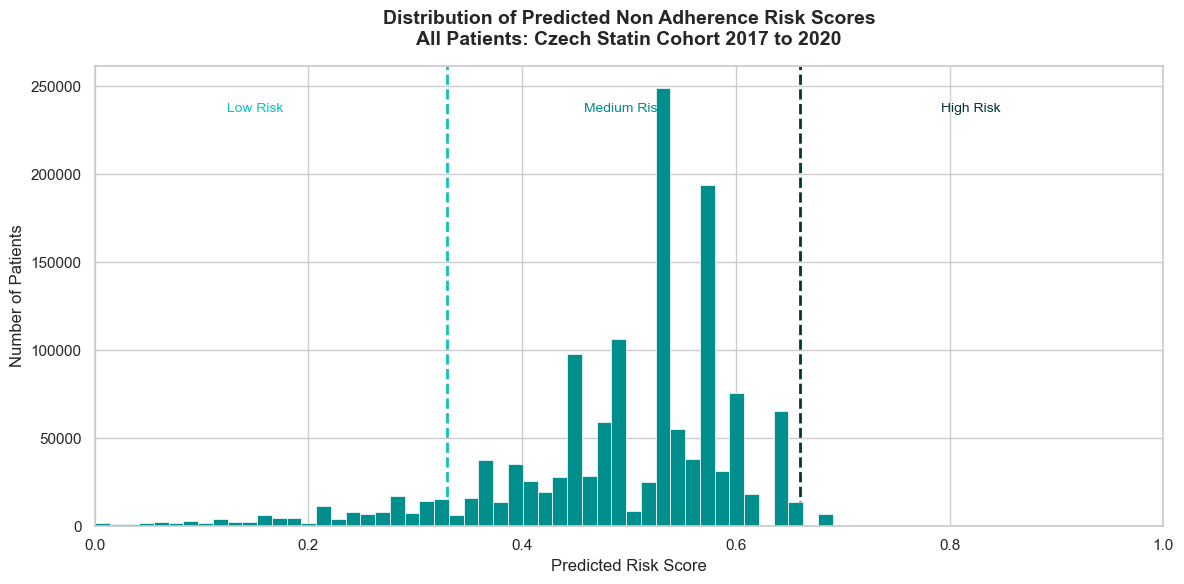

In [80]:
# PATIENT RISK SCORE DISTRIBUTION
# Author: Felicita_Adeleke | MSc Data Science | Health Analytics Portfolio

# Generate predicted risk scores for all patients
# Using balanced model for clinical appropriateness

y_prob_all = model_balanced.predict_proba(X_encoded)[:, 1]

patient_risk = df[[
    'patientid',
    'gender',
    'age_group',
    'incident',
    'order',
    'statin_intensity'
]].copy()

patient_risk['risk_score'] = y_prob_all

patient_risk['risk_band'] = pd.cut(
    patient_risk['risk_score'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Low', 'Medium', 'High']
)

# Print risk band distribution
print("=" * 30 + "|" + "=" * 30)
print("PATIENT RISK BAND DISTRIBUTION")
print("=" * 30 + "|" + "=" * 30)

total = len(patient_risk)

for band in ['Low', 'Medium', 'High']:
    count = (patient_risk['risk_band'] == band).sum()
    pct = count / total
    print(f"\n  {band} Risk")
    print(f"  Patients    : {count:,}")
    print(f"  Proportion  : {pct:.1%}")

print()
print("=" * 30 + "|" + "=" * 30)

# Visualise risk score distribution
plt.figure(figsize=(12, 6))

plt.hist(
    patient_risk['risk_score'],
    bins=50,
    color='#008F8C',
    edgecolor='white',
    linewidth=0.5
)

plt.axvline(
    0.33,
    color='#0FC2C0',
    linestyle='--',
    linewidth=2,
    zorder=0
)

plt.axvline(
    0.66,
    color='#023535',
    linestyle='--',
    linewidth=2,
    zorder=0
)

plt.text(
    0.15, 
    plt.gca().get_ylim()[1] * 0.9,
    'Low Risk',
    color='#0FC2C0',
    fontsize=10,
    ha='center'
)

plt.text(
    0.495,
    plt.gca().get_ylim()[1] * 0.9,
    'Medium Risk',
    color='#008F8C',
    fontsize=10,
    ha='center'
)
plt.xlim(0, 1.0)

plt.text(
    0.82,
    plt.gca().get_ylim()[1] * 0.9,
    'High Risk',
    color='#023535',
    fontsize=10,
    ha='center'
)


plt.title(
    'Distribution of Predicted Non Adherence Risk Scores\nAll Patients: Czech Statin Cohort 2017 to 2020',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel('Predicted Risk Score', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.tight_layout()
plt.show()

## Patient Risk Score Distribution: Findings and Interpretation

The distribution of predicted risk scores revealed 
an important characteristic of the model that has 
direct implications for how it should be used in 
a clinical setting.

Risk band distribution across 1,390,731 patients:

| Risk Band | Patients | Proportion |
|-----------|---------|------------|
| Low Risk | 132,387 | 9.5% |
| Medium Risk | 1,247,241 | 89.7% |
| High Risk | 11,103 | 0.8% |

The vast majority of patients fall within the 
medium risk band at 89.7%. Very few patients 
receive scores below 0.33 or above 0.66. The 
distribution peaks around 0.52 to 0.55 and is 
concentrated almost entirely between 0.35 and 
0.70.

This pattern tells an important clinical story.

The model does not produce highly polarised 
predictions. It does not clearly separate patients 
into obvious high and low risk groups. Instead it 
reflects the genuine complexity of medication 
adherence behaviour where risk exists on a 
continuous spectrum rather than as a binary 
state.

This has three important implications for 
clinical application.

First the model is more useful as a relative 
ranking tool than as an absolute classifier. 
Rather than asking which patients are high risk 
the more useful clinical question is which 
patients are highest risk relative to their 
peers. A patient scoring 0.65 represents 
meaningfully higher risk than one scoring 0.40 
even though both fall within the medium band.

Second the concentration of patients in the 
medium risk band suggests that intervention 
resources should not be reserved only for 
the small high risk group. The medium risk 
population of over 1.2 million patients 
contains the majority of those who will 
actually become non adherent. A tiered 
intervention approach targeting both medium 
and high risk patients would capture 
significantly more preventable discontinuations.

Third the small size of the high risk group 
at just 11,103 patients or 0.8% of the 
population makes intensive targeted 
intervention for this group highly feasible. 
These patients could realistically receive 
direct outreach from clinical teams within 
existing resource constraints.

Overall the risk score distribution confirms 
that this model functions most appropriately 
as a risk stratification tool to support 
clinical prioritisation rather than as a 
definitive diagnostic classifier. Used in 
this way it has genuine potential to improve 
the efficiency and effectiveness of adherence 
support programmes within a healthcare setting.

## Model Limitations and Considerations

No analytical model is without limitations and 
honest acknowledgement of those limitations is 
as important as reporting the findings themselves. 
In a healthcare context where model outputs may 
inform clinical decisions this transparency is 
not optional.

Four limitations of this analysis are acknowledged.

First the dataset covers the period 2017 to 2020 
which includes the early months of the COVID-19 
pandemic. Prescription collection behaviour was 
significantly disrupted during this period as 
patients faced barriers to pharmacy access, 
stockpiled medication, or avoided healthcare 
settings entirely. Some patients classified as 
non adherent in 2020 may reflect pandemic related 
disruption rather than genuine treatment 
discontinuation. The model may therefore 
overestimate non adherence rates for the 
period affected by COVID-19.

Second the dataset originates from the Czech 
Republic healthcare system. Prescribing patterns, 
patient demographics, healthcare access, and 
medication behaviour may differ meaningfully 
from those in the United Kingdom. Before applying 
this model operationally within an NHS context 
validation against UK prescription data would 
be essential to confirm that the patterns 
identified generalise across healthcare systems.

Third the model uses only five administrative 
variables. Clinically important factors known 
to influence medication adherence are not 
captured in this dataset. These include 
comorbidities, polypharmacy burden, socioeconomic 
status, health literacy, patient reported side 
effects, and the quality of the patient 
clinician relationship. A richer dataset 
incorporating these variables would likely 
produce a model with stronger discriminatory 
power and more nuanced risk stratification.

Fourth the model produces risk scores rather 
than causal explanations. A high risk score 
tells a healthcare team that a patient shares 
characteristics with those who have historically 
become non adherent. It does not tell them why 
that specific patient might stop their medication 
or what intervention would be most effective 
for them individually. The model supports 
clinical judgement but cannot replace it.

These limitations do not undermine the value 
of the analysis. They define the boundaries 
within which the findings should be interpreted 
and applied. A model that acknowledges its 
limitations is more trustworthy and more 
clinically useful than one that does not.

## Final Conclusion

This project set out to answer a question rooted 
in personal experience and clinical concern. How 
many patients quietly stop taking their heart 
medication and does anyone in the healthcare 
system notice before it is too late?

Using anonymised prescription claims data from 
890,000 patients across four years the analysis 
produced a coherent and clinically meaningful 
set of findings that address that question 
directly.

The exploratory analysis revealed that medication 
non adherence is not randomly distributed across 
the patient population. It follows clear and 
predictable patterns. Younger patients are 
significantly more at risk than older ones. 
Patients early in their treatment journey are 
far more vulnerable than those with established 
prescription histories. Gender and medication 
type add little additional predictive value 
when considered alongside age and treatment 
experience.

The predictive model confirmed and quantified 
these patterns. Age group 90 and above was the 
strongest protective factor with a coefficient 
of -0.934. Prescription order was the most 
actionable predictor with a coefficient of 
-0.363 identifying the early treatment window 
as the highest risk period for discontinuation.

The model was translated into an interactive 
Streamlit application allowing healthcare 
professionals to input patient characteristics 
and receive an instant predicted risk score 
and risk band without requiring any technical 
knowledge. Summary outputs were also exported 
for Power BI dashboard development to support 
population level reporting and performance 
monitoring.

The findings carry four direct clinical 
recommendations for any healthcare organisation 
seeking to reduce preventable cardiovascular 
harm through improved medication adherence.

First target younger patients proactively. 
Patients aged 30 to 44 have a non adherence 
rate of 43% and should receive dedicated 
adherence support as a standard component 
of their care pathway.

Second intervene early in the treatment 
journey. The largest single drop in non 
adherence occurs between the first and second 
prescription. A simple outreach programme 
at the 60 to 90 day mark after treatment 
initiation could prevent a significant 
proportion of early discontinuation.

Third use risk scores for prioritisation 
not classification. The model works best 
as a relative ranking tool helping clinical 
teams direct limited resources toward the 
patients most likely to benefit from 
proactive support.

Fourth validate before deploying. The 
findings are based on Czech prescription 
data from 2017 to 2020. Validation against 
UK NHS prescription data would be an 
essential next step before operational 
deployment within an NHS trust.

This project demonstrates that administrative 
prescription data already held within 
healthcare systems contains sufficient signal 
to meaningfully support earlier identification 
of patients at risk of medication non adherence. 
The analytical tools exist. The data exists. 
What is needed is the will to use them 
systematically to protect patients who are 
quietly at risk before that risk becomes 
irreversible harm.

In [84]:
import joblib

joblib.dump(
    model_balanced,
    r"C:\Users\felic\OneDrive\Healthcare_data_project\balanced_logistic_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!
